Test accuracy with adversarial attack for different epsilon

In [31]:

import torch
from flip.models import load_model
from flip.attacks import pgd
from flip.train import StandardTrainer, FLIPTrainer, AdversarialTrainer, TVTrainer, ATVTrainer
from flip.load_data import load_MNIST_test, load_MNIST, split_loader
from flip.utils.config import cfg, dataset, model_attributes
from flip.test import attack_model, eval_acc
import numpy as np
import matplotlib.pyplot as plt
import time 


In [32]:

# In this cell you can find the parameter that would be interesting to change
lenght = 40 # lenght of epsilon list
epsilon_test_list = np.logspace(-3, 0, lenght)
adversarial_test = "pgd" # "fgsm"

dataset_name = 'MNIST'
epochs = 5 # for each model : how many time is it trained

n_model = 1 # how many model are trained for every type of training



In [33]:


time_v = [time.time()]
for i in range(n_model-1):
    time_v.append(time_v[-1]+2)

CFG = cfg(data=dataset(name=dataset_name, download = False), 
          model = model_attributes(
              name = 'FC', 
              sizes=[784, 200, 80, 10],
              act_fun = 'ReLU',
              file_name = 'model_compare_adv_v' + str(round(time_v[0])) + '.pth',
              )
          )


In [34]:
# split data
dataloader, validation_loader, test_loader = split_loader(CFG, train_split=0.8)

In [35]:

def test_adversarial(epsilon_list, model_list, attack_type, loader = test_loader):
    lenghts = len(epsilon_list)
    acc_list = [0]*lenghts
    n_models = len(model_list)
    for e in range(lenghts):
        for i in range(n_models):
            CFG.model.file_name = model_list[i]
            model = load_model.load(CFG)
            acc_list[e] += attack_model(model, loader, attack_kwargs = {'type': attack_type, 'epsilon': epsilon_list[e]})
        acc_list[e] /= n_models
    return(acc_list)

[1726604013.642067]
init adv acc for ATV:  tensor(0.)
Begin ATV Training for model number  0
--------------------------------------------------
Epoch: 0
acc: tensor(0.1130)
loss: 0.017997907926638922
Approximation: 0.03
--------------------------------------------------
Epoch: 1
acc: tensor(0.1121)
loss: 0.017984297260642053
val_acc: 0.11325
Approximation: 0.009
--------------------------------------------------
Epoch: 2
acc: tensor(0.1121)
loss: 0.017982806781927745
val_acc: 0.11325
Approximation: 0.0026999999999999997
--------------------------------------------------
Epoch: 3
acc: tensor(0.6151)
loss: 0.014453665974239508
val_acc: 0.11325
Approximation: 0.0008099999999999998
--------------------------------------------------
Epoch: 4
acc: tensor(0.8500)
loss: 0.012619537817935149
val_acc: 0.008166666666666666
Approximation: 0.00024299999999999994
Training model :model_compare_adv_v1726604014.pth
init adv acc for adversarial:  tensor(0.)
Begin Adversarial Training for model number  0

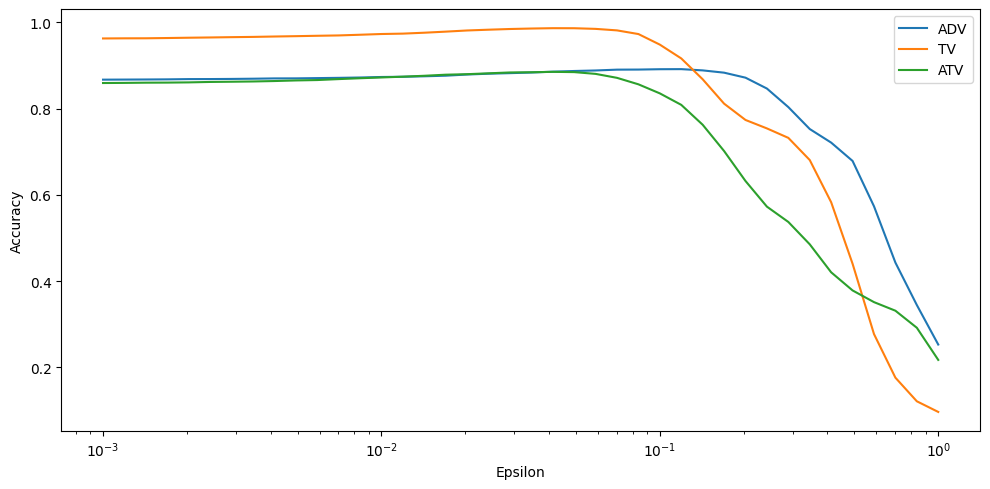

In [36]:



elapsed_time_ADV = 0
elapsed_time_TV = 0
elapsed_time_ATV = 0

print(time_v)

for i in range(n_model):
    CFG.model.file_name = 'model_compare_ATV_v' + str(round(time_v[i])) + '.pth'
    model_ATV = load_model.load(CFG)
    trainer = ATVTrainer(model_ATV, dataloader, val_loader=validation_loader,
                        lamda=0.07,
                        num_iters=2,
                        approximation_decrep=0.3,
                        opt_kwargs={'type': torch.optim.Adam },
                        adv_kwargs={'type' : "fgsm", 'epsilon' : 0.05},
                        verbosity=1,
                        epochs=epochs,
                        min_acc=1.,
                        cfg = CFG,)
    print('init adv acc for ATV: ', attack_model(model_ATV, dataloader, attack_kwargs = {'type':"fgsm", 'epsilon':1., 'max_iters':1})) # Expected to be near 0
    print('Begin ATV Training for model number ', i)
    start_time = time.time()
    trainer.train()
    elapsed_time_ATV += (time.time() - start_time)/n_model

model_list = ['model_compare_ATV_v' + str(round(time_v[i])) + '.pth' for i in range(len(time_v))]
    
acc_ATV = test_adversarial(epsilon_test_list, model_list, adversarial_test)

for i in range(n_model):
    CFG.model.file_name = 'model_compare_adv_v' + str(round(time_v[i])) + '.pth'
    print('Training model :' + CFG.model.file_name)
    model_ADV = load_model.load(CFG)
    trainer = AdversarialTrainer(model_ADV, dataloader, val_loader=validation_loader,
                            opt_kwargs={'type': torch.optim.Adam },
                            adv_kwargs = {'type' : "fgsm", 'epsilon' : 0.05},
                            verbosity=1,
                            epochs=epochs,
                            cfg = CFG,)
    print('init adv acc for adversarial: ', attack_model(model_ADV, dataloader, attack_kwargs = {'type':"fgsm", 'epsilon':1., 'max_iters':1})) # Expected to be near 0
    print('Begin Adversarial Training for model number ', i)
    start_time = time.time()
    trainer.train()
    elapsed_time_ADV += (time.time() - start_time)/n_model

model_list = ['model_compare_adv_v' + str(round(time_v[i])) + '.pth' for i in range(len(time_v))]
    
acc_ADV = test_adversarial(epsilon_test_list, model_list, adversarial_test)


for i in range(n_model):
    CFG.model.file_name = 'model_compare_TV_v' + str(round(time_v[i])) + '.pth'
    model_TV = load_model.load(CFG)
    trainer = TVTrainer(model_TV, dataloader, val_loader=validation_loader,
                        lamda=0.7,
                        num_iters=2,
                        approximation_decrep=0.3,
                        opt_kwargs={'type': torch.optim.Adam },
                        upd_kwargs={'name' : 'SGD', 'lr' : 0.07},
                        verbosity=1,
                        epochs=epochs,
                        min_acc=1.,
                        cfg = CFG,)
    print('init adv acc for TV: ', attack_model(model_TV, dataloader, attack_kwargs = {'type':"fgsm", 'epsilon':1., 'max_iters':1})) # Expected to be near 0
    print('Begin TV Training for model number ', i)
    start_time = time.time()
    trainer.train()
    elapsed_time_TV += (time.time() - start_time)/n_model

model_list = ['model_compare_TV_v' + str(round(time_v[i])) + '.pth' for i in range(len(time_v))]
    
acc_TV = test_adversarial(epsilon_test_list, model_list, adversarial_test)
    

print('time TV: ', elapsed_time_TV)
print('time ADV: ', elapsed_time_ADV)
print('time ATV: ', elapsed_time_ATV)

plt.figure(figsize=(10, 5))

# Plot acc
plt.plot(epsilon_test_list, acc_ADV, label='ADV')
plt.plot(epsilon_test_list, acc_TV, label='TV')
plt.plot(epsilon_test_list, acc_ATV, label='ATV')
plt.xlabel('Epsilon')
plt.xscale('log')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()
